In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\pc\Downloads\archive (23)\ecommerce_customer_churn_large.csv")
df.head()

,customer_id,age,gender,city,tenure_months,avg_order_value,total_orders,last_purchase_days_ago,support_tickets,subscription_type,churn
0,100000,56,Female,Mumbai,82,7722,56,704,49,Basic,1
1,100001,69,Female,Kolkata,28,2127,248,357,39,Basic,0
2,100002,46,Male,Delhi,98,2775,68,121,23,Platinum,0
3,100003,32,Female,Pune,46,1698,309,39,47,Silver,0
4,100004,60,Female,Bangalore,90,6520,147,403,32,Silver,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   customer_id             200000 non-null  int64 
 1   age                     200000 non-null  int64 
 2   gender                  200000 non-null  object
 3   city                    200000 non-null  object
 4   tenure_months           200000 non-null  int64 
 5   avg_order_value         200000 non-null  int64 
 6   total_orders            200000 non-null  int64 
 7   last_purchase_days_ago  200000 non-null  int64 
 8   support_tickets         200000 non-null  int64 
 9   subscription_type       200000 non-null  object
 10  churn                   200000 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 16.8+ MB


In [4]:
df.churn.value_counts(normalize=True)

churn
0    0.627865
1    0.372135
Name: proportion, dtype: float64

In [5]:
df.drop(columns='customer_id',inplace=True)

In [6]:
df.nunique()

age                         52
gender                       2
city                         7
tenure_months              119
avg_order_value           9800
total_orders               499
last_purchase_days_ago     730
support_tickets             50
subscription_type            4
churn                        2
dtype: int64

In [7]:
df['gender']=df['gender'].map({'Female':0,'Male':1})

In [8]:
obj_cols=df.select_dtypes(include='object').columns.tolist()
num_cols=df.select_dtypes(exclude='object').columns.tolist()

In [9]:
obj_cols
num_cols.remove('churn')
num_cols

['age',
 'gender',
 'tenure_months',
 'avg_order_value',
 'total_orders',
 'last_purchase_days_ago',
 'support_tickets']

In [10]:
df.head()

,age,gender,city,tenure_months,avg_order_value,total_orders,last_purchase_days_ago,support_tickets,subscription_type,churn
0,56,0,Mumbai,82,7722,56,704,49,Basic,1
1,69,0,Kolkata,28,2127,248,357,39,Basic,0
2,46,1,Delhi,98,2775,68,121,23,Platinum,0
3,32,0,Pune,46,1698,309,39,47,Silver,0
4,60,0,Bangalore,90,6520,147,403,32,Silver,0


In [11]:
X=df.drop(columns='churn')
Y=df['churn']

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

In [13]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
scaler=StandardScaler()
ohe=OneHotEncoder()
x_train_scaled=scaler.fit_transform(x_train[num_cols])
x_test_scaled=scaler.transform(x_test[num_cols])
x_train_ohe=ohe.fit_transform(x_train[obj_cols])
x_test_ohe=ohe.transform(x_test[obj_cols])

In [14]:
ohe_feature_names = ohe.get_feature_names_out(obj_cols)
all_features = list(num_cols) + list(ohe_feature_names)


x_train_combined = np.hstack((x_train_scaled, x_train_ohe.toarray()))

x_train_df = pd.DataFrame(
    x_train_combined, 
    columns=all_features, 
    index=x_train.index 
)

x_test_combined = np.hstack((x_test_scaled, x_test_ohe.toarray()))

x_test_df = pd.DataFrame(
    x_test_combined, 
    columns=all_features, 
    index=x_test.index   
)

from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)

X_resampled, y_resampled = adasyn.fit_resample(x_train_df, y_train)

In [15]:
# For XGBoost
from xgboost import XGBClassifier, XGBRegressor

# For LightGBM
from lightgbm import LGBMClassifier, LGBMRegressor

xgb_model = XGBClassifier()
lgb_model = LGBMClassifier()

In [16]:
xgb_model.fit(X_resampled,y_resampled)
pred=xgb_model.predict(x_test_df)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,pred))

[[18282  6655]
 [ 7920  7143]]


In [17]:
xgb_params = {
    "max_depth": [3,5,6],
    "learning_rate": [0.01,0.05,0.08,0.1],
    "n_estimators": [100,200,300]
}
from sklearn.model_selection import RandomizedSearchCV
rcv=RandomizedSearchCV(xgb_model,xgb_params)
search=rcv.fit(x_train_df,y_train)
search.best_params_

{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}

In [18]:
xgbc=XGBClassifier(n_estimators= 200, max_depth= 3, learning_rate= 0.08)
xgbc.fit(X_resampled,y_resampled)
predict=xgbc.predict(x_test_df)
print(confusion_matrix(y_test,predict))

[[15550  9387]
 [ 5730  9333]]


**from the above models, it is better to use xgb_model which has not undergone hyperparameter tuning as it perfoms better on precision as compared to xgbc**

In [27]:
from sklearn.metrics import precision_recall_curve,PrecisionRecallDisplay,f1_score
precision, recall, thresholds = precision_recall_curve(
    y_test, pred)

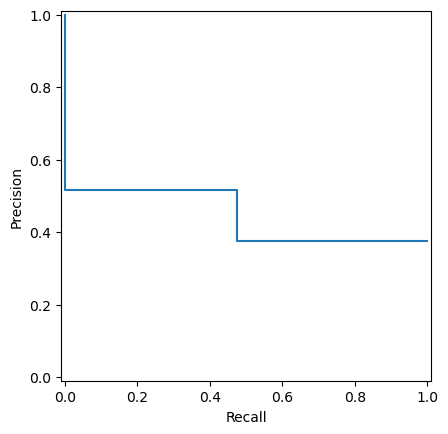

In [28]:
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

In [ ]:
f1_scores = (2 * precision * recall) / (precision + recall + 1e-8)

# Locate the index of the highest F1-score
# (Excluding the last element of precision/recall because thresholds array is 1 element shorter)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold (Max F1-Score): {best_threshold:.4f}")
print(f"Best F1-Score: {f1_scores[best_idx]:.4f}")
print(f"Resulting Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}")

**The above focuses on Recall but we want to prioritize Precision so that our predictions for churning customers is closer to being accurate**

In [30]:
# Define beta. A beta of 0.5 prioritizes precision over recall.
beta = 0.5

# Calculate F-beta array
f_beta_scores = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)

# Find the threshold that maximizes F-beta
best_idx = np.argmax(f_beta_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold (Max F0.5-Score): {best_threshold:.4f}")
print(f"Resulting Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}")

Optimal Threshold (Max F0.5-Score): 1.0000
Resulting Precision: 0.5177, Recall: 0.4742


**we are adjusting the threshold to favour precision which we have been able to determine above**

In [32]:
# 1. Get the raw probabilities for the positive class (class 1)
y_probs = xgb_model.predict_proba(x_test_df)[:, 1]

# 2. Set your custom threshold
custom_threshold = 0.5177

# 3. Apply the threshold to generate new binary predictions
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Now you can pass y_pred_custom to your classification report or confusion matrix
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.69      0.77      0.73     24937
           1       0.53      0.42      0.47     15063

    accuracy                           0.64     40000
   macro avg       0.61      0.60      0.60     40000
weighted avg       0.63      0.64      0.63     40000



In [33]:
print(confusion_matrix(y_test,y_pred_custom))

[[19256  5681]
 [ 8676  6387]]
